# Fase 1 — Sección 2: Exploración tabla por tabla
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

**Prerequisito:** Ejecutar primero `01_exploracion_limpieza.ipynb` no es necesario,
este notebook es autocontenido con su propia configuración mínima.

---

---
<a id='seccion-0'></a>
## Sección 0 — Configuración y conexión

In [2]:
PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}

print('Constantes cargadas.')

Constantes cargadas.


In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Librerias importadas correctamente.')
print(f'Figuras en: {FIGURES_DIR}')

Librerias importadas correctamente.
Figuras en: C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\reports\figures


In [4]:
# ── Conexión con SQLAlchemy ───────────────────────────────────────────────────
DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    result  = conn.execute(text('SELECT version()'))
    version = result.fetchone()[0]

print('Conexion establecida correctamente.')
print(f'   PostgreSQL: {version.split(",")[0]}')

Conexion establecida correctamente.
   PostgreSQL: PostgreSQL 18.3 on x86_64-windows


In [5]:
# ── Funciones helper ──────────────────────────────────────────────────────────
def query(sql: str, params: dict = None) -> pd.DataFrame:
    """Ejecuta una SELECT y devuelve el resultado como DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)


def execute(sql: str, params: dict = None) -> int:
    """Ejecuta un INSERT/UPDATE/DELETE. Devuelve el numero de filas afectadas."""
    with engine.begin() as conn:
        result = conn.execute(text(sql), params or {})
        return result.rowcount


def tabla_info(nombre_tabla: str) -> pd.DataFrame:
    """Devuelve la estructura (columnas, tipos, nulos) de una tabla."""
    sql = """
        SELECT column_name AS columna, data_type AS tipo,
               is_nullable AS permite_nulos, column_default AS valor_defecto
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = :tabla
        ORDER BY ordinal_position
    """
    return query(sql, {'tabla': nombre_tabla})


def nulos_tabla(nombre_tabla: str) -> pd.DataFrame:
    """Cuenta nulos por columna en una tabla dada."""
    columnas = query(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema='public' AND table_name=:t ORDER BY ordinal_position",
        {'t': nombre_tabla}
    )['column_name'].tolist()
    partes    = [f'COUNT(*) FILTER (WHERE "{c}" IS NULL) AS "{c}"' for c in columnas]
    resultado = query(f"SELECT {', '.join(partes)} FROM {nombre_tabla}")
    total     = query(f"SELECT COUNT(*) AS total FROM {nombre_tabla}")['total'].iloc[0]
    df        = resultado.T.reset_index()
    df.columns = ['columna', 'nulos']
    df['total']     = total
    df['pct_nulos'] = (df['nulos'] / total * 100).round(2)
    return df[df['nulos'] > 0].sort_values('nulos', ascending=False)


print('Funciones helper definidas: query(), execute(), tabla_info(), nulos_tabla()')

Funciones helper definidas: query(), execute(), tabla_info(), nulos_tabla()


---
<a id='seccion-2'></a>
## Sección 2 — Exploración tabla por tabla

Exploración en profundidad de las 17 tablas agrupadas por sistema de origen.
Para cada tabla: estructura, muestra de datos, estadísticas y observaciones.

---
### 2.1 — CRM: `customer`

In [6]:
# ── Estructura ────────────────────────────────────────────────────────────────
print('=== TABLA: customer ===')
display(tabla_info('customer'))

=== TABLA: customer ===


,columna,tipo,permite_nulos,valor_defecto
0,customer_id,integer,NO,nextval('customer_customer_id_seq1'::regclass)
1,first_name,character varying,YES,None
2,last_name,character varying,YES,None
3,last_name2,character varying,YES,None
4,email,character varying,YES,None
5,phone,character varying,YES,None
6,created_at,timestamp without time zone,YES,CURRENT_TIMESTAMP


In [7]:
# ── Muestra y estadísticas ────────────────────────────────────────────────────
df_customer = query('SELECT * FROM customer')
print(f'Filas: {len(df_customer):,}  |  Columnas: {df_customer.shape[1]}')
display(df_customer.head(5))
display(df_customer.describe(include='all').T)

Filas: 5,750  |  Columnas: 7


,customer_id,first_name,last_name,last_name2,email,phone,created_at
0,1,Marta,Ruiz,García,marta.ruiz1@example.com,+34 6987791,2018-11-15 04:51:29.131242
1,2,Alejandro,López,López,alejandro.lópez2@example.com,+34 669926134,2018-09-07 20:45:28.751233
2,3,Alejandro,López,Álvarez,alejandro.lópez3@example.com,+34 661558537,2019-02-09 06:54:03.656551
3,4,Javier,Ruiz,Fernández,javier.ruiz4@example.com,+34 671059371,2018-05-15 04:21:48.773057
4,5,David,Gómez,Pérez,david.gómez5@example.com,+34 610619856,2019-12-31 21:44:05.438027


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,5750.00,NaN,NaN,NaN,2877.24,1.00,1440.25,2877.50,4314.75,5752.00,1660.42
first_name,5750,184,Alejandro,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,5750,189,Martínez,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name2,5750,189,Sánchez,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,5750,5750,marta.ruiz1@example.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone,5750,5750,+34 6987791,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,5750,NaN,NaN,NaN,2025-04-24 20:13:25.330473472,2018-01-01 03:38:29.909295,2026-04-04 14:00:45.206380032,2026-04-06 14:05:51.530479104,2026-04-06 14:05:51.530479104,2026-04-06 14:05:51.530479,NaN


In [8]:
# ── Longitud de telefonos ─────────────────────────────────────────────────────
df_customer['tel_len'] = df_customer['phone'].astype(str).str.len()
tel_dist = df_customer['tel_len'].value_counts().sort_index()

print('Distribucion de longitud de telefonos:')
print('=' * 42)
print(f'  {"Longitud":<12} {"Clientes":>10}  {"% Total":>8}')
print('-' * 42)
for longitud, cnt in tel_dist.items():
    pct    = cnt / len(df_customer) * 100
    alerta = '  ⚠' if longitud != 13 else ''
    print(f'  {longitud:<12} {cnt:>10,.0f}  {pct:>7.2f}%{alerta}')
print('=' * 42)
incorrectos = df_customer[df_customer['tel_len'] != 13]
print(f'\nTelefonos con longitud incorrecta: {len(incorrectos):,}')

Distribucion de longitud de telefonos:
  Longitud       Clientes   % Total
------------------------------------------
  10                    4     0.07%  ⚠
  11                   47     0.82%  ⚠
  12                  517     8.99%  ⚠
  13                5,182    90.12%

Telefonos con longitud incorrecta: 568


In [9]:
# ── Nombres duplicados ────────────────────────────────────────────────────────
df_customer['nombre_completo'] = df_customer['first_name'] + ' ' + df_customer['last_name']
dup_nombres = df_customer['nombre_completo'].value_counts()
dup_nombres = dup_nombres[dup_nombres > 1]

print(f'Clientes con nombre+apellido duplicado: {len(dup_nombres):,}')
print(f'Registros afectados: {dup_nombres.sum():,}')
print('\nTop 10 nombres mas repetidos:')
print('=' * 42)
for nombre, cnt in dup_nombres.head(10).items():
    print(f'  {nombre:<30} {cnt:>4} veces')
print('=' * 42)
print('\nNota: no es un error — customer_id es unico.')

Clientes con nombre+apellido duplicado: 1,060
Registros afectados: 2,930

Top 10 nombres mas repetidos:
  Sergio Martínez                  14 veces
  Marta Martínez                   14 veces
  David Díaz                       13 veces
  Alejandro Fernández              13 veces
  Carlos Fernández                 12 veces
  Sergio Díaz                      11 veces
  Javier Gómez                     11 veces
  Laura Fernández                  11 veces
  María Álvarez                    11 veces
  María García                     11 veces

Nota: no es un error — customer_id es unico.


In [10]:
# ── Distribucion de zonas ─────────────────────────────────────────────────────
df_city_zone = query('SELECT * FROM city_zone ORDER BY postal_code')

print('=' * 52)
print('  DISTRIBUCION DE ZONAS — city_zone')
print('=' * 52)
print(f'  Total zonas: {len(df_city_zone)}')
print('=' * 52)

# Por tipo de area
if 'area_type' in df_city_zone.columns:
    print('\nPor tipo de area:')
    print('-' * 38)
    for tipo, cnt in df_city_zone['area_type'].value_counts().items():
        pct = cnt / len(df_city_zone) * 100
        print(f'  {tipo:<20} {cnt:>4}  ({pct:.1f}%)')

# Por orientacion
if 'zone_orientation' in df_city_zone.columns:
    print('\nPor orientacion:')
    print('-' * 38)
    for ori, cnt in df_city_zone['zone_orientation'].value_counts().items():
        pct = cnt / len(df_city_zone) * 100
        print(f'  {str(ori):<20} {cnt:>4}  ({pct:.1f}%)')
print('=' * 52)
print('\nNota: customer no tiene FK directa a city_zone en este modelo.')

  DISTRIBUCION DE ZONAS — city_zone
  Total zonas: 42

Por tipo de area:
--------------------------------------
  Periférica             23  (54.8%)
  Céntrica               19  (45.2%)

Por orientacion:
--------------------------------------
  Centro                 14  (33.3%)
  Norte                   7  (16.7%)
  Sureste                 5  (11.9%)
  Suroeste                4  (9.5%)
  Noreste                 4  (9.5%)
  Sur                     3  (7.1%)
  Este                    2  (4.8%)
  Noroeste                2  (4.8%)

Nota: customer no tiene FK directa a city_zone en este modelo.


> **Observaciones `customer`:**
> - 568 teléfonos con longitud incorrecta → se conservan, no reconstruibles
> - 2.930 clientes comparten nombre+apellido → no es error, `customer_id` es único
> - Distribución geográfica concentrada en pocas zonas

---
### 2.2 — CRM: `city_zone`

In [11]:
# ── Estructura y muestra ──────────────────────────────────────────────────────
print('=== TABLA: city_zone ===')
display(tabla_info('city_zone'))
df_city_zone = query('SELECT * FROM city_zone ORDER BY postal_code')
print(f'\nFilas: {len(df_city_zone)}')
display(df_city_zone.head(10))

# Distribucion por tipo de zona
if 'zone_type' in df_city_zone.columns:
    print('\nDistribucion por tipo de zona:')
    print('=' * 38)
    for tipo, cnt in df_city_zone['zone_type'].value_counts().items():
        pct = cnt / len(df_city_zone) * 100
        print(f'  {tipo:<20} {cnt:>4}  ({pct:.1f}%)')
    print('=' * 38)

=== TABLA: city_zone ===


,columna,tipo,permite_nulos,valor_defecto
0,postal_code,character varying,NO,None
1,district,character varying,NO,None
2,area_type,character varying,YES,None
3,zone_orientation,character varying,YES,None
4,city_code,character varying,YES,28
5,city,character varying,YES,'Madrid'::character varying



Filas: 42


,postal_code,district,area_type,zone_orientation,city_code,city
0,28001,Salamanca,Céntrica,Centro,28,Madrid
1,28002,Chamartín,Céntrica,Norte,28,Madrid
2,28003,Chamberí,Céntrica,Centro,28,Madrid
3,28004,Centro,Céntrica,Centro,28,Madrid
4,28005,Centro,Céntrica,Centro,28,Madrid
5,28006,Salamanca,Céntrica,Centro,28,Madrid
6,28008,Moncloa-Aravaca,Céntrica,Noroeste,28,Madrid
7,28009,Retiro,Céntrica,Centro,28,Madrid
8,28010,Chamberí,Céntrica,Centro,28,Madrid
9,28012,Centro,Céntrica,Centro,28,Madrid


---
### 2.3 — ERP Catálogo: `product` y `central_product`

In [12]:
# ── Estructura y muestra ──────────────────────────────────────────────────────
print('=== TABLA: product ===')
display(tabla_info('product'))
df_product = query('SELECT * FROM product ORDER BY product_id')
display(df_product.head(5))

print('\n=== TABLA: central_product ===')
display(tabla_info('central_product'))
df_cp = query('SELECT * FROM central_product ORDER BY product_id')
display(df_cp.head(5))

=== TABLA: product ===


,columna,tipo,permite_nulos,valor_defecto
0,product_id,integer,NO,nextval('product_product_id_seq'::regclass)
1,name,character varying,NO,None
2,category,character varying,YES,None
3,manufacturer,character varying,YES,None
4,price,numeric,NO,None
5,created_at,timestamp without time zone,YES,CURRENT_TIMESTAMP


,product_id,name,category,manufacturer,price,created_at
0,1,Tensiómetro digital,Diagnóstico,Omron,59.99,2026-04-04 11:23:48.591695
1,2,Oxímetro de pulso,Diagnóstico,Beurer,29.99,2026-04-04 11:23:48.591695
2,3,Termómetro infrarrojo,Diagnóstico,Medisana,24.90,2026-04-04 11:23:48.591695
3,4,Báscula inteligente,Wellness,Xiaomi,34.99,2026-04-04 11:23:48.591695
4,5,Monitor de glucosa,Diagnóstico,Abbott,79.99,2026-04-04 11:23:48.591695



=== TABLA: central_product ===


,columna,tipo,permite_nulos,valor_defecto
0,product_id,integer,NO,None
1,name,character varying,NO,None
2,category_id,integer,YES,None
3,brand_id,integer,YES,None
4,sku,character varying,YES,None
5,barcode,character varying,YES,None
6,unit_cost,numeric,YES,None
7,unit_price,numeric,YES,None


,product_id,name,category_id,brand_id,sku,barcode,unit_cost,unit_price
0,1,Tensiómetro digital,1,1,SKU-1,BC-1,35.99,59.99
1,2,Oxímetro de pulso,1,2,SKU-2,BC-2,17.99,29.99
2,3,Termómetro infrarrojo,1,3,SKU-3,BC-3,14.94,24.90
3,4,Báscula inteligente,2,4,SKU-4,BC-4,20.99,34.99
4,5,Monitor de glucosa,1,5,SKU-5,BC-5,47.99,79.99


In [13]:
# ── Cruce product vs central_product ─────────────────────────────────────────
ids_product = set(df_product['product_id'])
ids_cp      = set(df_cp['product_id'])

solo_en_product = ids_product - ids_cp
solo_en_cp      = ids_cp - ids_product
en_ambas        = ids_product & ids_cp

print('=' * 50)
print('  CRUCE product vs central_product')
print('=' * 50)
print(f'  Productos en ambas tablas    : {len(en_ambas):>4}')
print(f'  Solo en product              : {len(solo_en_product):>4}', end='')
print(f'  -> IDs: {solo_en_product}' if solo_en_product else '')
print(f'  Solo en central_product      : {len(solo_en_cp):>4}', end='')
print(f'  -> IDs: {solo_en_cp}' if solo_en_cp else '')
print('=' * 50)

if solo_en_product:
    print('\n⚠  Productos sin coste en central_product:')
    display(df_product[df_product['product_id'].isin(solo_en_product)])

  CRUCE product vs central_product
  Productos en ambas tablas    :   50
  Solo en product              :    0
  Solo en central_product      :    0


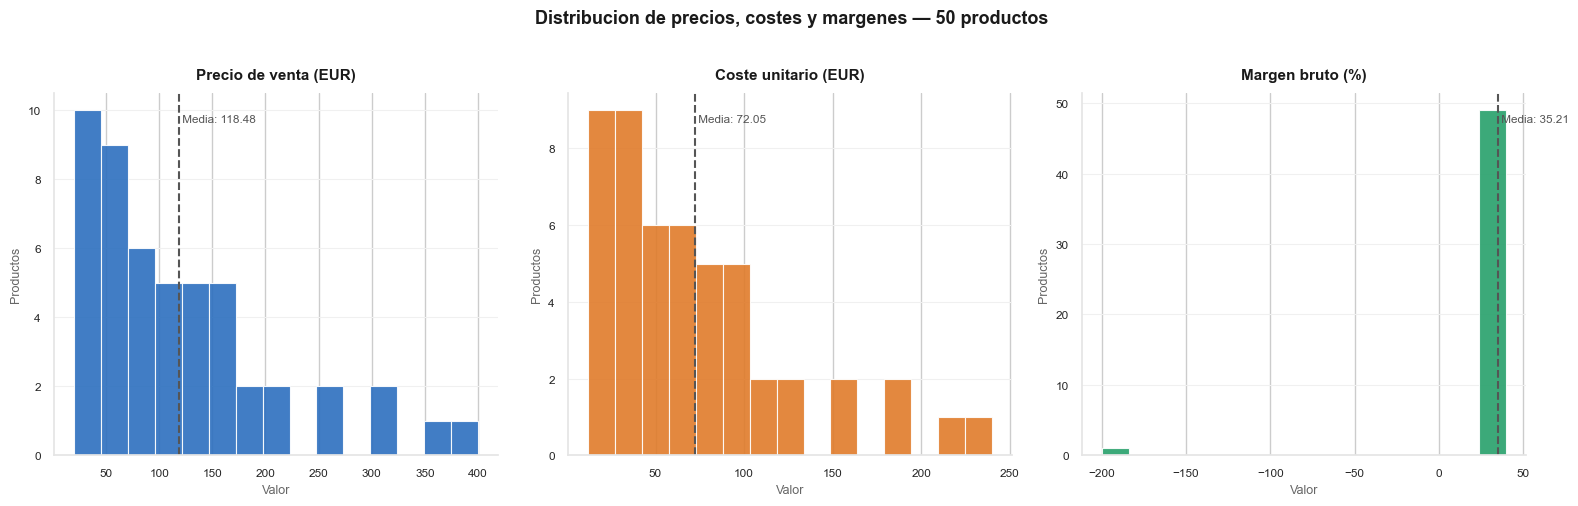


Estadisticas de precio, coste y margen:


,count,mean,std,min,25%,50%,75%,max
price,50.00,118.48,88.37,19.99,51.22,94.94,149.99,399.99
cost,50.00,72.05,52.36,11.99,33.70,59.94,89.99,239.99
margen_abs,50.00,46.44,37.05,-39.95,20.49,37.98,60.00,160.00
margen_pct,50.00,35.21,33.92,-199.85,40.00,40.00,40.01,40.02


In [14]:
# ── Distribucion de precios y costes ─────────────────────────────────────────
df_prod_full = query("""
    SELECT p.product_id, p.name AS nombre,
           p.price,
           cp.unit_cost AS cost,
           p.price - cp.unit_cost AS margen_abs,
           ROUND((p.price - cp.unit_cost) / NULLIF(p.price, 0) * 100, 2) AS margen_pct
    FROM product p
    LEFT JOIN central_product cp ON p.product_id = cp.product_id
    ORDER BY margen_pct DESC NULLS LAST
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax, col, titulo, color in zip(
    axes,
    ['price', 'cost', 'margen_pct'],
    ['Precio de venta (EUR)', 'Coste unitario (EUR)', 'Margen bruto (%)'],
    [PALETA['ERP'], PALETA['Logistica'], PALETA['CRM']]
):
    datos = df_prod_full[col].dropna()
    ax.hist(datos, bins=15, color=color, edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.axvline(datos.mean(), color='#555555', linewidth=1.5, linestyle='--')
    ax.text(datos.mean(), ax.get_ylim()[1] * 0.92,
            f' Media: {datos.mean():.2f}', fontsize=8.5, color='#555555')
    ax.set_title(titulo, fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)
    ax.set_xlabel('Valor', fontsize=9, color='#666666')
    ax.set_ylabel('Productos', fontsize=9, color='#666666')
    ax.tick_params(labelsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#E5E5E5')
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='#F0F0F0', linewidth=0.8)

fig.suptitle('Distribucion de precios, costes y margenes — 50 productos',
             fontsize=13, fontweight='bold', color='#1A1A1A', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_precios_costes_margenes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nEstadisticas de precio, coste y margen:')
display(df_prod_full[['price','cost','margen_abs','margen_pct']].describe().T)

> **Observaciones `product` / `central_product`:**
> - Producto 29 (Sensor temperatura inteligente) tiene precio incorrecto: 19.99€ cuando debería ser 99.90€
> - Todos los productos de su categoría tienen margen fijo del 40% → precio correcto = coste / 0.60 = 59.94 / 0.60 = 99.90€
> - Se corregirá en Sección 5 actualizando el precio en la tabla `product`

---
### 2.4 — ERP Catálogo: `brand` y `category`

In [80]:
# ── brand ─────────────────────────────────────────────────────────────────────
df_brand = query('SELECT * FROM brand ORDER BY brand_id')
print(f'=== TABLA: brand  ({len(df_brand)} registros) ===')
display(df_brand)

# Productos por marca
df_prod_brand = query("""
    SELECT b.name AS brand_name, COUNT(cp.product_id) AS productos
    FROM brand b
    LEFT JOIN central_product cp ON b.brand_id = cp.brand_id
    GROUP BY b.name
    ORDER BY productos DESC
""")
print('\nProductos por marca:')
print('=' * 38)
for _, row in df_prod_brand.iterrows():
    print(f'  {row["brand_name"]:<25} {row["productos"]:>3} producto{"s" if row["productos"] != 1 else ""}')
print('=' * 38)

=== TABLA: brand  (29 registros) ===


,brand_id,name,country,website
0,1,Omron,Japón,https://omronhealthcare.com
1,2,Beurer,Alemania,https://beurer.com
2,3,Medisana,Alemania,https://medisana.com
3,4,Xiaomi,China,https://mi.com
4,5,Abbott,Estados Unidos,https://abbott.com
5,6,Oral-B,Estados Unidos,https://oralb.com
6,7,Philips,Países Bajos,https://philips.com
7,8,Naipo,China,None
8,9,Compex,Suiza,https://compex.com
9,10,AliveCor,Estados Unidos,https://alivecor.com



Productos por marca:
  Beurer                      4 productos
  Omron                       4 productos
  Xiaomi                      4 productos
  Invacare                    4 productos
  Naipo                       2 productos
  Abbott                      2 productos
  Withings                    2 productos
  Philips                     2 productos
  Medisana                    2 productos
  Thermoval                   2 productos
  Oral-B                      2 productos
  Compex                      2 productos
  Ortones                     2 productos
  Seca                        1 producto
  Therabody                   1 producto
  Fisioclinic                 1 producto
  Dyson                       1 producto
  Viatom                      1 producto
  AliveCor                    1 producto
  RespiPro                    1 producto
  Rowenta                     1 producto
  Oxycare                     1 producto
  Lumie                       1 producto
  Sonoline            

In [81]:
# ── category ──────────────────────────────────────────────────────────────────
df_category = query('SELECT * FROM category ORDER BY category_id')
print(f'=== TABLA: category  ({len(df_category)} registros) ===')
display(df_category)

# Productos por categoria
df_prod_cat = query("""
    SELECT c.name AS category_name, COUNT(cp.product_id) AS productos
    FROM category c
    LEFT JOIN central_product cp ON c.category_id = cp.category_id
    GROUP BY c.name
    ORDER BY productos DESC
""")
print('\nProductos por categoria:')
print('=' * 38)
for _, row in df_prod_cat.iterrows():
    print(f'  {row["category_name"]:<25} {row["productos"]:>3} productos')
print('=' * 38)

=== TABLA: category  (6 registros) ===


,category_id,name,description
0,1,Diagnóstico,Productos de medición y monitoreo.
1,2,Wellness,Productos de bienestar y salud general.
2,3,Movilidad,Productos de apoyo a movilidad.
3,4,Rehabilitación,Equipos de recuperación y fisioterapia.
4,5,Higiene,Equipos y dispositivos sanitarios.
5,6,Tratamiento,Productos y equipos para tratamientos específicos



Productos por categoria:
  Diagnóstico                15 productos
  Wellness                   14 productos
  Rehabilitación              7 productos
  Tratamiento                 5 productos
  Movilidad                   5 productos
  Higiene                     4 productos


---
### 2.5 — ERP Transaccional: `sale` y `sale_item`

In [82]:
# ── Estructura y muestra ──────────────────────────────────────────────────────
print('=== TABLA: sale ===')
display(tabla_info('sale'))
df_sale = query('SELECT * FROM sale ORDER BY sale_id')
display(df_sale.head(5))
display(df_sale.describe().T)

print('\n=== TABLA: sale_item ===')
display(tabla_info('sale_item'))
df_sale_item = query('SELECT * FROM sale_item ORDER BY sale_id, sale_item_id')
display(df_sale_item.head(5))
display(df_sale_item.describe().T)

=== TABLA: sale ===


,columna,tipo,permite_nulos,valor_defecto
0,sale_id,integer,NO,nextval('sale_sale_id_seq'::regclass)
1,customer_id,integer,YES,None
2,store_id,integer,YES,None
3,sale_date,timestamp without time zone,NO,None
4,total,numeric,YES,None


,sale_id,customer_id,store_id,sale_date,total
0,3,160,15,2023-09-23 10:23:26.643082,359.98
1,4,298,5,2020-10-18 02:06:58.749665,399.99
2,5,212,20,2021-02-03 18:50:47.573929,399.84
3,6,95,9,2021-01-24 14:37:46.625466,549.75
4,7,594,16,2020-02-19 03:47:49.052471,119.90


,count,mean,min,25%,50%,75%,max,std
sale_id,20000.00,10253.00,3.00,5002.75,10002.50,15252.75,21004.00,6105.81
customer_id,20000.00,1092.93,1.00,246.00,498.00,750.75,5752.00,1452.82
store_id,20000.00,9.96,1.00,5.00,10.00,15.00,20.00,5.92
sale_date,20000,2023-03-20 23:17:46.462806016,2020-01-01 03:41:35.198837,2021-09-26 22:48:14.454087936,2023-04-20 23:52:05.203790080,2024-11-02 16:46:32.469365504,2025-12-30 23:52:53.702142,NaN
total,20000.00,483.93,19.99,149.97,359.98,719.49,3089.71,420.04



=== TABLA: sale_item ===


,columna,tipo,permite_nulos,valor_defecto
0,sale_item_id,integer,NO,nextval('sale_item_sale_item_id_seq'::regclass)
1,sale_id,integer,YES,None
2,product_id,integer,YES,None
3,quantity,integer,NO,None
4,unit_price,numeric,NO,None
5,offer_id,integer,YES,None
6,subtotal,numeric,NO,None


,sale_item_id,sale_id,product_id,quantity,unit_price,offer_id,subtotal
0,1,3,46,2,179.99,NaN,359.98
1,2,4,45,1,399.99,NaN,399.99
2,3,5,35,1,59.99,NaN,59.99
3,4,5,22,3,79.99,NaN,239.97
4,5,5,2,2,29.99,NaN,59.98


,count,mean,std,min,25%,50%,75%,max
sale_item_id,42555.00,21395.73,12467.55,1.00,10639.50,21278.00,31916.50,43557.00
sale_id,42555.00,8796.65,5421.83,3.00,4262.00,8488.00,12761.00,21004.00
product_id,42555.00,25.49,14.43,1.00,13.00,26.00,38.00,50.00
quantity,42555.00,1.92,0.82,1.00,1.00,2.00,3.00,3.00
unit_price,42555.00,118.49,87.76,19.99,49.99,89.99,149.99,399.99
offer_id,8.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
subtotal,42555.00,227.44,206.47,19.99,79.99,159.98,299.98,1199.97


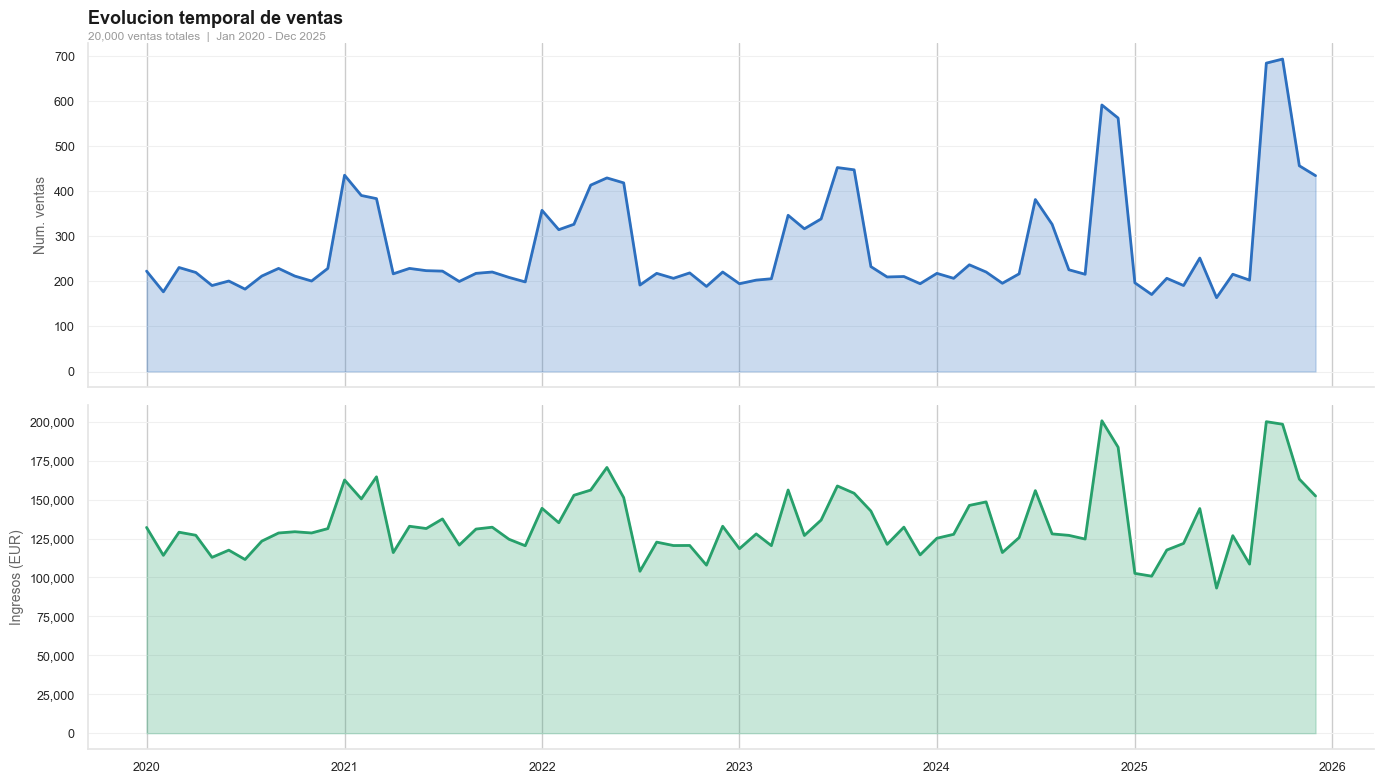

In [83]:
# ── Evolucion temporal de ventas ──────────────────────────────────────────────
df_ventas_mes = query("""
    SELECT
        DATE_TRUNC('month', sale_date)  AS mes,
        COUNT(*)                         AS num_ventas,
        SUM(total)                       AS ingresos
    FROM sale
    GROUP BY mes
    ORDER BY mes
""")
df_ventas_mes['mes'] = pd.to_datetime(df_ventas_mes['mes'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('white')

# Panel superior: numero de ventas
ax1.fill_between(df_ventas_mes['mes'], df_ventas_mes['num_ventas'],
                 alpha=0.25, color=PALETA['ERP'])
ax1.plot(df_ventas_mes['mes'], df_ventas_mes['num_ventas'],
         color=PALETA['ERP'], linewidth=2)
ax1.set_ylabel('Num. ventas', fontsize=10, color='#666666')
ax1.set_title('Evolucion temporal de ventas', fontsize=13,
              fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax1.text(0, 1.01, f'{len(df_sale):,.0f} ventas totales  |  {df_ventas_mes["mes"].min().strftime("%b %Y")} - {df_ventas_mes["mes"].max().strftime("%b %Y")}',
         transform=ax1.transAxes, fontsize=8.5, color='#999999')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#E5E5E5')
ax1.yaxis.grid(True, color='#F0F0F0', linewidth=0.8)
ax1.tick_params(labelsize=9)

# Panel inferior: ingresos
ax2.fill_between(df_ventas_mes['mes'], df_ventas_mes['ingresos'],
                 alpha=0.25, color=PALETA['CRM'])
ax2.plot(df_ventas_mes['mes'], df_ventas_mes['ingresos'],
         color=PALETA['CRM'], linewidth=2)
ax2.set_ylabel('Ingresos (EUR)', fontsize=10, color='#666666')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#E5E5E5')
ax2.yaxis.grid(True, color='#F0F0F0', linewidth=0.8)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_evolucion_ventas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

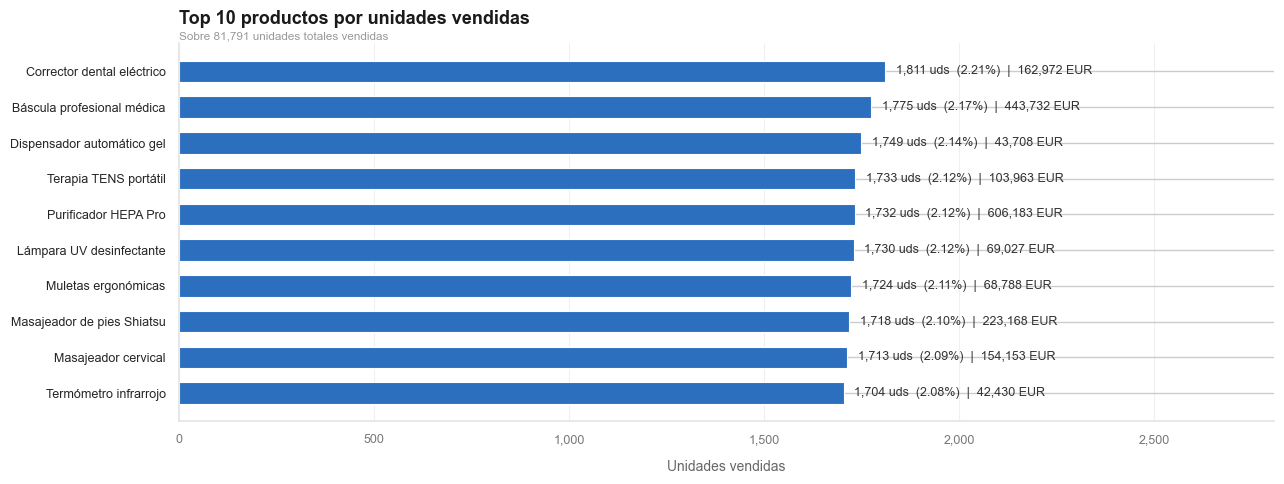

In [84]:
# ── Top 10 productos mas vendidos ─────────────────────────────────────────────
df_top_prod = query("""
    SELECT p.name AS product_name,
           SUM(si.quantity)                 AS unidades,
           SUM(si.quantity * si.unit_price) AS ingresos
    FROM sale_item si
    JOIN product p ON si.product_id = p.product_id
    GROUP BY p.name
    ORDER BY unidades DESC
    LIMIT 10
""")

total_u = query('SELECT SUM(quantity) AS total FROM sale_item')['total'].iloc[0]
df_top_prod_plot = df_top_prod.sort_values('unidades', ascending=True)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')

bars = ax.barh(df_top_prod_plot['product_name'], df_top_prod_plot['unidades'],
               color=PALETA['ERP'], edgecolor='white', linewidth=0.8, height=0.6)

max_v = df_top_prod_plot['unidades'].max()
for bar, val, ing in zip(bars, df_top_prod_plot['unidades'], df_top_prod_plot['ingresos']):
    pct = val / total_u * 100
    ax.text(bar.get_width() + max_v * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} uds  ({pct:.2f}%)  |  {ing:,.0f} EUR',
            va='center', ha='left', fontsize=9, color='#333333')

ax.set_title('Top 10 productos por unidades vendidas', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'Sobre {total_u:,.0f} unidades totales vendidas',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Unidades vendidas', fontsize=10, color='#666666', labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.55)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_top_productos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [85]:
# ── Verificacion venta 13009 ──────────────────────────────────────────────────
df_13009_total = query("SELECT sale_id, total FROM sale WHERE sale_id = 13009")
df_13009_items = query("""
    SELECT sale_id, SUM(quantity * unit_price) AS total_calculado
    FROM sale_item WHERE sale_id = 13009 GROUP BY sale_id
""")

total_bd   = df_13009_total['total'].iloc[0]
total_calc = df_13009_items['total_calculado'].iloc[0]
diferencia = total_bd - total_calc

print('=' * 48)
print('  VERIFICACION VENTA 13009')
print('=' * 48)
print(f'  Total en BD          : {total_bd:>10.2f} EUR')
print(f'  Total calculado      : {total_calc:>10.2f} EUR')
print(f'  Diferencia           : {diferencia:>10.2f} EUR', end='')
print('  ⚠  ERROR DETECTADO' if abs(diferencia) > 0.01 else '  OK')
print('=' * 48)

  VERIFICACION VENTA 13009
  Total en BD          :     321.77 EUR
  Total calculado      :     334.76 EUR
  Diferencia           :     -12.99 EUR  ⚠  ERROR DETECTADO


In [86]:
# ── Lineas con offer_id NULL ──────────────────────────────────────────────────
df_desc_null = query("""
    SELECT * FROM sale_item
    WHERE offer_id IS NULL
""")

total_items = query('SELECT COUNT(*) AS total FROM sale_item')['total'].iloc[0]
con_oferta  = query('SELECT COUNT(*) AS total FROM sale_item WHERE offer_id IS NOT NULL')['total'].iloc[0]
sin_oferta  = len(df_desc_null)

print('=' * 48)
print('  ANALISIS DE offer_id EN sale_item')
print('=' * 48)
print(f'  Total lineas          : {total_items:>8,.0f}')
print(f'  Con offer_id          : {con_oferta:>8,.0f}  ({con_oferta/total_items*100:.2f}%)')
print(f'  Sin offer_id (NULL)   : {sin_oferta:>8,.0f}  ({sin_oferta/total_items*100:.2f}%)')
print('=' * 48)

  ANALISIS DE offer_id EN sale_item
  Total lineas          :   42,555
  Con offer_id          :        8  (0.02%)
  Sin offer_id (NULL)   :   42,547  (99.98%)


> **Observaciones `sale` / `sale_item`:**
> - Venta 13009 con total erróneo (+3 EUR) → se corregirá en Sección 5
> - 8 líneas con descuento aplicado pero `offer_id` NULL → se corregirá en Sección 5
> - Exploración temporal muestra la distribución de ventas a lo largo del tiempo

---
### 2.6 — ERP: `offer` y `product_offer`

In [87]:
# ── offer ─────────────────────────────────────────────────────────────────────
df_offer = query('SELECT * FROM offer')
print(f'=== TABLA: offer  ({len(df_offer)} registro) ===')
display(tabla_info('offer'))
display(df_offer)

# product_offer
df_po = query('SELECT * FROM product_offer')
print(f'\n=== TABLA: product_offer  ({len(df_po)} registros) ===')
display(tabla_info('product_offer'))
display(df_po)

print('\nProductos con oferta activa:')
df_po_detail = query("""
    SELECT po.product_id, p.name AS product_name,
           o.name AS offer_name, o.discount_percent
    FROM product_offer po
    JOIN product p ON po.product_id = p.product_id
    JOIN offer o   ON po.offer_id   = o.offer_id
""")
display(df_po_detail)

=== TABLA: offer  (1 registro) ===


,columna,tipo,permite_nulos,valor_defecto
0,offer_id,integer,NO,nextval('offer_offer_id_seq'::regclass)
1,name,character varying,YES,None
2,description,text,YES,None
3,discount_percent,numeric,YES,None
4,start_date,date,NO,None
5,end_date,date,NO,None


,offer_id,name,description,discount_percent,start_date,end_date
0,1,Semana Salud,Oferta por campaña salud,10.00,2024-05-01,2024-05-07



=== TABLA: product_offer  (6 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,product_id,integer,NO,None
1,offer_id,integer,NO,None


,product_id,offer_id
0,1,1
1,2,1
2,3,1
3,5,1
4,15,1
5,30,1



Productos con oferta activa:


,product_id,product_name,offer_name,discount_percent
0,1,Tensiómetro digital,Semana Salud,10.00
1,2,Oxímetro de pulso,Semana Salud,10.00
2,3,Termómetro infrarrojo,Semana Salud,10.00
3,5,Monitor de glucosa,Semana Salud,10.00
4,15,Lámpara de fototerapia,Semana Salud,10.00
5,30,Monitor sueño portátil,Semana Salud,10.00


In [88]:
display(tabla_info('store'))
display(tabla_info('sale'))

,columna,tipo,permite_nulos,valor_defecto
0,store_id,integer,NO,nextval('store_store_id_seq'::regclass)
1,name,character varying,NO,None
2,address,character varying,YES,None
3,city,character varying,YES,'Madrid'::character varying
4,postal_code,character varying,YES,None
5,latitude,numeric,YES,None
6,longitude,numeric,YES,None
7,opened_date,date,YES,CURRENT_DATE


,columna,tipo,permite_nulos,valor_defecto
0,sale_id,integer,NO,nextval('sale_sale_id_seq'::regclass)
1,customer_id,integer,YES,None
2,store_id,integer,YES,None
3,sale_date,timestamp without time zone,NO,None
4,total,numeric,YES,None


---
### 2.7 — ERP: `store` e `inventory`

=== TABLA: store  (20 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,store_id,integer,NO,nextval('store_store_id_seq'::regclass)
1,name,character varying,NO,None
2,address,character varying,YES,None
3,city,character varying,YES,'Madrid'::character varying
4,postal_code,character varying,YES,None
5,latitude,numeric,YES,None
6,longitude,numeric,YES,None
7,opened_date,date,YES,CURRENT_DATE


,store_id,name,address,city,postal_code,latitude,longitude,opened_date
0,1,Store Retiro,Calle Alcalá 85,Madrid,28009,40.42,-3.67,2026-04-04
1,2,Store Salamanca,Calle Goya 45,Madrid,28001,40.43,-3.68,2026-04-04
2,3,Store Chamartín,Calle Serrano 210,Madrid,28016,40.46,-3.68,2026-04-04
3,4,Store La Latina,Cava Baja 25,Madrid,28005,40.41,-3.71,2026-04-04
4,5,Store Sol,Puerta del Sol 3,Madrid,28013,40.42,-3.70,2026-04-04
5,6,Store Moncloa,Calle Princesa 90,Madrid,28008,40.43,-3.72,2026-04-04
6,7,Store Atocha,Atocha 73,Madrid,28012,40.41,-3.69,2026-04-04
7,8,Store Vallecas,Av. de la Albufera 100,Madrid,28018,40.39,-3.66,2026-04-04
8,9,Store Usera,Av. Rafaela Ybarra 45,Madrid,28026,40.38,-3.71,2026-04-04
9,10,Store Carabanchel,Calle General Ricardos 120,Madrid,28019,40.39,-3.72,2026-04-04


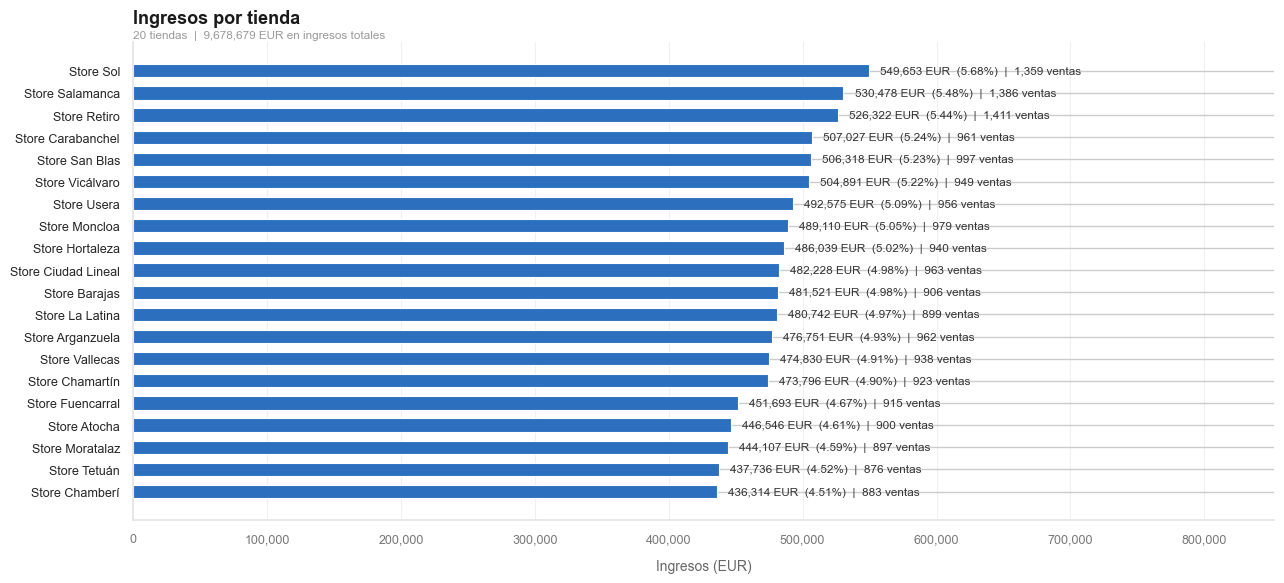

In [89]:
# ── store ─────────────────────────────────────────────────────────────────────
df_store = query('SELECT * FROM store ORDER BY store_id')
print(f'=== TABLA: store  ({len(df_store)} registros) ===')
display(tabla_info('store'))
display(df_store)

# Ventas por tienda
df_ventas_tienda = query("""
    SELECT s.name AS store_name,
           COUNT(sa.sale_id) AS num_ventas,
           SUM(sa.total)     AS ingresos
    FROM store s
    LEFT JOIN sale sa ON s.store_id = sa.store_id
    GROUP BY s.name
    ORDER BY ingresos DESC
""")

total_ing = df_ventas_tienda['ingresos'].sum()
df_vt_plot = df_ventas_tienda.sort_values('ingresos', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

bars = ax.barh(df_vt_plot['store_name'], df_vt_plot['ingresos'],
               color=PALETA['ERP'], edgecolor='white', linewidth=0.8, height=0.6)

max_v = df_vt_plot['ingresos'].max()
for bar, val, nv in zip(bars, df_vt_plot['ingresos'], df_vt_plot['num_ventas']):
    pct = val / total_ing * 100
    ax.text(bar.get_width() + max_v * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} EUR  ({pct:.2f}%)  |  {nv:,.0f} ventas',
            va='center', ha='left', fontsize=8.5, color='#333333')

ax.set_title('Ingresos por tienda', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'{len(df_store)} tiendas  |  {total_ing:,.0f} EUR en ingresos totales',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Ingresos (EUR)', fontsize=10, color='#666666', labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.55)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_ingresos_por_tienda.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [90]:
# ── inventory ─────────────────────────────────────────────────────────────────
df_inv = query('SELECT * FROM inventory')
print(f'=== TABLA: inventory  ({len(df_inv)} registros) ===')
display(tabla_info('inventory'))
display(df_inv.describe().T)

# Stock cero o negativo
sin_stock = df_inv[df_inv['stock'] <= 0]
print(f'\nRegistros con stock <= 0: {len(sin_stock)}')
if len(sin_stock) > 0:
    display(sin_stock)
else:
    print('OK — no hay registros con stock <= 0')

=== TABLA: inventory  (1000 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,inventory_id,integer,NO,nextval('inventory_inventory_id_seq'::regclass)
1,store_id,integer,YES,None
2,product_id,integer,YES,None
3,stock,integer,YES,None
4,last_update,timestamp without time zone,YES,CURRENT_TIMESTAMP


,count,mean,min,25%,50%,75%,max,std
inventory_id,1000.00,500.50,1.00,250.75,500.50,750.25,1000.00,288.82
store_id,1000.00,10.50,1.00,5.75,10.50,15.25,20.00,5.77
product_id,1000.00,25.50,1.00,13.00,25.50,38.00,50.00,14.44
stock,1000.00,1.92,0.00,1.00,2.00,3.00,4.00,1.39
last_update,1000,2026-04-04 12:31:02.168720640,2026-04-04 12:31:02.168721,2026-04-04 12:31:02.168720896,2026-04-04 12:31:02.168720896,2026-04-04 12:31:02.168720896,2026-04-04 12:31:02.168721,NaN



Registros con stock <= 0: 202


,inventory_id,store_id,product_id,stock,last_update
3,4,1,4,0,2026-04-04 12:31:02.168721
12,13,1,13,0,2026-04-04 12:31:02.168721
13,15,1,15,0,2026-04-04 12:31:02.168721
15,17,1,17,0,2026-04-04 12:31:02.168721
20,22,1,22,0,2026-04-04 12:31:02.168721
...,...,...,...,...,...
986,414,9,14,0,2026-04-04 12:31:02.168721
989,564,12,14,0,2026-04-04 12:31:02.168721
990,643,13,43,0,2026-04-04 12:31:02.168721
993,793,16,43,0,2026-04-04 12:31:02.168721


---
### 2.8 — Logística: `warehouse`, `warehouse_location`, `central_inventory`

In [91]:
# ── warehouse ─────────────────────────────────────────────────────────────────
df_wh = query('SELECT * FROM warehouse')
print(f'=== TABLA: warehouse  ({len(df_wh)} registro) ===')
display(tabla_info('warehouse'))
display(df_wh)

# warehouse_location
df_whl = query('SELECT * FROM warehouse_location ORDER BY location_id')
print(f'\n=== TABLA: warehouse_location  ({len(df_whl)} registros) ===')
display(tabla_info('warehouse_location'))
display(df_whl.head(10))

# central_inventory
df_ci = query('SELECT * FROM central_inventory ORDER BY product_id')
print(f'\n=== TABLA: central_inventory  ({len(df_ci)} registros) ===')
display(tabla_info('central_inventory'))
display(df_ci.describe().T)

=== TABLA: warehouse  (1 registro) ===


,columna,tipo,permite_nulos,valor_defecto
0,warehouse_id,integer,NO,nextval('warehouse_warehouse_id_seq'::regclass)
1,name,character varying,NO,None
2,address,character varying,YES,None
3,city,character varying,YES,None
4,postal_code,character varying,YES,None
5,latitude,numeric,YES,None
6,longitude,numeric,YES,None


,warehouse_id,name,address,city,postal_code,latitude,longitude
0,1,Almacén Central Madrid,Calle del Haya 4,Madrid,28044,40.37,-3.75



=== TABLA: warehouse_location  (40 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,location_id,integer,NO,nextval('warehouse_location_location_id_seq'::...
1,warehouse_id,integer,YES,None
2,zone,character varying,YES,None
3,aisle,character varying,YES,None
4,shelf,character varying,YES,None
5,bin_code,character varying,YES,None


,location_id,warehouse_id,zone,aisle,shelf,bin_code
0,1,1,Zona A,1,2,B1
1,2,1,Zona A,1,3,B2
2,3,1,Zona A,1,4,B3
3,4,1,Zona A,1,5,B4
4,5,1,Zona A,2,1,B5
5,6,1,Zona A,2,2,B6
6,7,1,Zona A,2,3,B7
7,8,1,Zona A,2,4,B8
8,9,1,Zona A,2,5,B9
9,10,1,Zona A,3,1,B10



=== TABLA: central_inventory  (49 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,inventory_id,integer,NO,nextval('central_inventory_inventory_id_seq'::...
1,warehouse_id,integer,YES,None
2,location_id,integer,YES,None
3,product_id,integer,YES,None
4,quantity,integer,NO,0
5,min_stock,integer,YES,0
6,max_stock,integer,YES,0
7,last_update,timestamp without time zone,YES,CURRENT_TIMESTAMP


,count,mean,min,25%,50%,75%,max,std
inventory_id,49.00,25.00,1.00,13.00,25.00,37.00,49.00,14.29
warehouse_id,49.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
location_id,49.00,19.82,1.00,11.00,18.00,27.00,40.00,11.20
product_id,49.00,25.43,1.00,13.00,25.00,38.00,50.00,14.72
quantity,49.00,53.82,1.00,34.00,50.00,76.00,100.00,27.95
min_stock,49.00,5.00,5.00,5.00,5.00,5.00,5.00,0.00
max_stock,49.00,200.00,200.00,200.00,200.00,200.00,200.00,0.00
last_update,49,2026-04-04 20:30:50.917114880,2026-04-04 20:30:50.917115,2026-04-04 20:30:50.917114880,2026-04-04 20:30:50.917114880,2026-04-04 20:30:50.917114880,2026-04-04 20:30:50.917115,NaN


In [92]:
display(tabla_info('return_reason'))
display(tabla_info('return_item'))

,columna,tipo,permite_nulos,valor_defecto
0,reason_id,integer,NO,nextval('return_reason_reason_id_seq'::regclass)
1,reason,text,YES,None
2,active,boolean,YES,true


,columna,tipo,permite_nulos,valor_defecto
0,return_id,integer,NO,nextval('return_item_return_id_seq'::regclass)
1,sale_item_id,integer,YES,None
2,return_date,timestamp without time zone,NO,None
3,quantity,integer,NO,None
4,reason_id,integer,YES,None


---
### 2.9 — Postventa: `return_item` y `return_reason`

=== TABLA: return_reason  (6 registros) ===


,reason_id,reason,active
0,1,No cumple expectativas,True
1,2,Producto defectuoso,True
2,3,Error en el pedido,True
3,4,Problema de funcionamiento,True
4,5,Cliente arrepentido,True
5,6,Desconocida,False



=== TABLA: return_item  (2330 registros) ===


,columna,tipo,permite_nulos,valor_defecto
0,return_id,integer,NO,nextval('return_item_return_id_seq'::regclass)
1,sale_item_id,integer,YES,None
2,return_date,timestamp without time zone,NO,None
3,quantity,integer,NO,None
4,reason_id,integer,YES,None


,return_id,sale_item_id,return_date,quantity,reason_id
0,1,17311,2022-01-22 21:51:09.811617,1,1
1,2,7825,2022-07-08 20:44:32.457955,1,4
2,3,25893,2025-02-21 00:13:16.118776,1,1
3,4,29857,2022-06-14 19:27:41.014434,1,1
4,5,26690,2024-09-23 21:56:52.250072,1,4


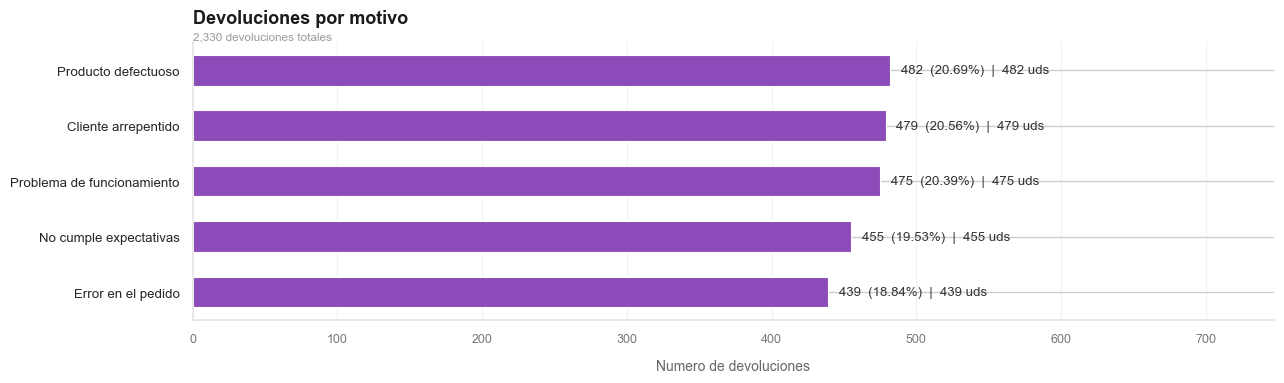


Tasa de devolucion global: 5.48%  (2,330 devoluciones / 42,555 lineas de venta)


In [93]:
# ── return_reason ─────────────────────────────────────────────────────────────
df_rr = query('SELECT * FROM return_reason ORDER BY reason_id')
print(f'=== TABLA: return_reason  ({len(df_rr)} registros) ===')
display(df_rr)

# return_item
df_ri = query('SELECT * FROM return_item ORDER BY return_id')
print(f'\n=== TABLA: return_item  ({len(df_ri)} registros) ===')
display(tabla_info('return_item'))
display(df_ri.head(5))

# ── Devoluciones por motivo ───────────────────────────────────────────────────
df_devol_motivo = query("""
    SELECT rr.reason AS motivo,
           COUNT(ri.return_id) AS devoluciones,
           SUM(ri.quantity)    AS unidades
    FROM return_item ri
    JOIN return_reason rr ON ri.reason_id = rr.reason_id
    GROUP BY rr.reason
    ORDER BY devoluciones DESC
""")

total_dev  = df_devol_motivo['devoluciones'].sum()
df_dm_plot = df_devol_motivo.sort_values('devoluciones', ascending=True)

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('white')

bars = ax.barh(df_dm_plot['motivo'], df_dm_plot['devoluciones'],
               color=PALETA['Postventa'], edgecolor='white', linewidth=0.8, height=0.55)

max_v = df_dm_plot['devoluciones'].max()
for bar, val, uds in zip(bars, df_dm_plot['devoluciones'], df_dm_plot['unidades']):
    pct = val / total_dev * 100
    ax.text(bar.get_width() + max_v * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}  ({pct:.2f}%)  |  {uds:,.0f} uds',
            va='center', ha='left', fontsize=9.5, color='#333333')

ax.set_title('Devoluciones por motivo', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'{total_dev:,.0f} devoluciones totales',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Numero de devoluciones', fontsize=10, color='#666666', labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='y', labelsize=9.5)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.55)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_devoluciones_por_motivo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Tasa de devolucion global
total_ventas_items = query('SELECT COUNT(*) AS total FROM sale_item')['total'].iloc[0]
tasa = total_dev / total_ventas_items * 100
print(f'\nTasa de devolucion global: {tasa:.2f}%  ({total_dev:,.0f} devoluciones / {total_ventas_items:,.0f} lineas de venta)')

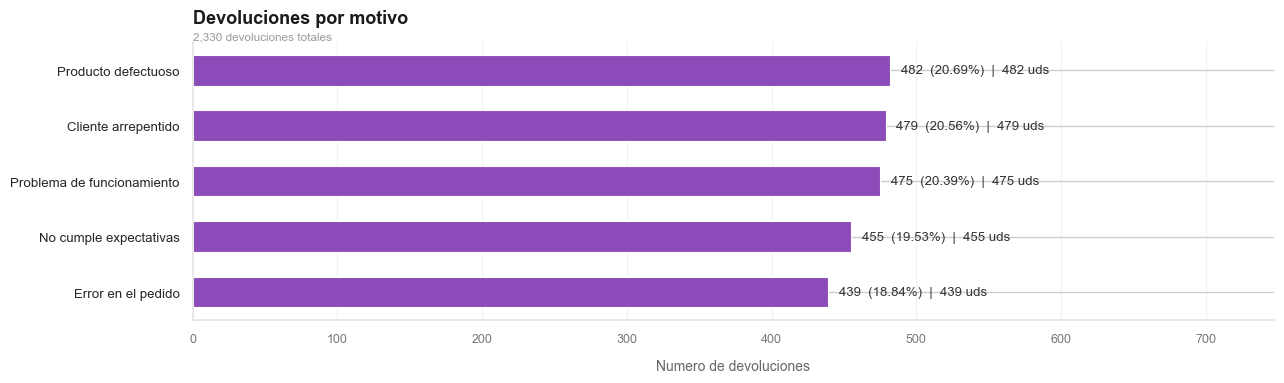


Tasa de devolucion global: 5.48%  (2,330 devoluciones / 42,555 lineas de venta)


In [94]:
# ── Devoluciones por motivo ───────────────────────────────────────────────────
df_devol_motivo = query("""
    SELECT rr.reason AS motivo,
           COUNT(ri.return_id) AS devoluciones,
           SUM(ri.quantity)    AS unidades
    FROM return_item ri
    JOIN return_reason rr ON ri.reason_id = rr.reason_id
    GROUP BY rr.reason
    ORDER BY devoluciones DESC
""")

total_dev = df_devol_motivo['devoluciones'].sum()
df_dm_plot = df_devol_motivo.sort_values('devoluciones', ascending=True)

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('white')

bars = ax.barh(df_dm_plot['motivo'], df_dm_plot['devoluciones'],
               color=PALETA['Postventa'], edgecolor='white', linewidth=0.8, height=0.55)

max_v = df_dm_plot['devoluciones'].max()
for bar, val, uds in zip(bars, df_dm_plot['devoluciones'], df_dm_plot['unidades']):
    pct = val / total_dev * 100
    ax.text(bar.get_width() + max_v * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}  ({pct:.2f}%)  |  {uds:,.0f} uds',
            va='center', ha='left', fontsize=9.5, color='#333333')

ax.set_title('Devoluciones por motivo', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'{total_dev:,.0f} devoluciones totales',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Numero de devoluciones', fontsize=10, color='#666666', labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='y', labelsize=9.5)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.55)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_devoluciones_por_motivo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Tasa de devolucion global
total_ventas_items = query('SELECT COUNT(*) AS total FROM sale_item')['total'].iloc[0]
tasa = total_dev / total_ventas_items * 100
print(f'\nTasa de devolucion global: {tasa:.2f}%  ({total_dev:,.0f} devoluciones / {total_ventas_items:,.0f} lineas de venta)')

> **Observaciones `return_item` / `return_reason`:**
> - Tasa de devolución global calculada sobre líneas de venta
> - Motivos distribuidos entre 6 categorías
> - Esta información alimentará la métrica **Return Rate** en la Fase de CLTV

---
### 2.10 — Cruce `sale` ↔ `customer`

In [95]:
# ── Integridad referencial rapida: clientes en ventas ─────────────────────────
df_cruce = query("""
    SELECT
        COUNT(DISTINCT s.customer_id)                          AS clientes_con_ventas,
        COUNT(DISTINCT c.customer_id)                          AS total_clientes,
        COUNT(DISTINCT s.customer_id) FILTER
            (WHERE c.customer_id IS NULL)                      AS clientes_huerfanos
    FROM sale s
    LEFT JOIN customer c ON s.customer_id = c.customer_id
""")

total_c         = df_cruce['total_clientes'].iloc[0]
con_ventas      = df_cruce['clientes_con_ventas'].iloc[0]
huerfanos       = df_cruce['clientes_huerfanos'].iloc[0]
sin_ventas      = total_c - con_ventas

print('=' * 52)
print('  CRUCE sale <-> customer')
print('=' * 52)
print(f'  Total clientes en BD          : {total_c:>6,.0f}')
print(f'  Clientes con al menos 1 venta : {con_ventas:>6,.0f}  ({con_ventas/total_c*100:.2f}%)')
print(f'  Clientes sin ninguna venta    : {sin_ventas:>6,.0f}  ({sin_ventas/total_c*100:.2f}%)')
print(f'  Ventas con customer_id huerfano: {huerfanos:>5,.0f}', end='')
print('  ⚠' if huerfanos > 0 else '  OK')
print('=' * 52)

print('\nSeccion 2 completada - exploracion tabla por tabla finalizada.')

  CRUCE sale <-> customer
  Total clientes en BD          :  5,750
  Clientes con al menos 1 venta :  5,750  (100.00%)
  Clientes sin ninguna venta    :      0  (0.00%)
  Ventas con customer_id huerfano:     0  OK

Seccion 2 completada - exploracion tabla por tabla finalizada.
